# Generalized calibration (shared parameters)

In this notebook, you will:
- choose which specimens enter a **joint** fit (and their relative weights)
- set one shared SteelMPF seed / free-parameter / loss configuration
- optimize one parameter vector for the whole group
- check **validation** specimens the fit never saw: one path-ordered BRB plus
  digitized clouds (including a multi-amplitude drive)

**Requirement:** each train Name needs path-ordered resampled data
(`data/resampled/{Name}/force_deformation.csv`). Digitized unordered specimens
cannot enter the joint fit, but they can be validation checks (via `J_binenv`).
Catalog `generalized_weight` is ignored here — use `TRAIN_SPECIMENS` weights
instead (default 1).

Edit the **Parameters** cell, then run the remaining cells in order.

Outputs: `results/notebooks/generalized/`.


## Browse the specimen catalog

Before you pick a specimen name, look at what is in the repo:

- a **table** from `config/calibration/BRB-Specimens.csv` (geometry + layout flags)
- a **grid of raw hysteresis** from `data/raw/{Name}/` (unfiltered)

Path-ordered tests draw as loops; digitized tests draw as points.
Then edit **Parameters** below and choose a `Name` you like.


,Name,experimental_layout,path_ordered,f_yc_ksi,A_c_in2,A_t_in2,L_T_in,L_y_in,individual_optimize,generalized_weight
0,PC250,raw,true,41.30,5.96,59.60,251.96,179.40,true,1
1,PC350,raw,true,41.30,8.34,83.40,252.02,183.30,true,1
2,PC160,raw,true,41.30,3.80,38.00,252.00,176.00,true,1
3,PC500,raw,true,37.90,12.66,126.60,251.98,185.10,true,1
4,PC750A,raw,true,37.90,17.85,178.50,251.98,184.20,true,1
5,PC750B,raw,true,37.90,17.87,178.70,251.96,179.40,true,1
6,PC1200A,raw,true,37.90,28.53,285.30,252.02,185.20,true,1
7,PC1200B,raw,true,37.90,28.62,286.20,251.96,181.30,true,1
8,PC3SB,digitized,true,40.00,5.00,50.00,116.00,78.00,true,1
9,A5,digitized,false,44.08,5.66,56.60,215.55,148.70,false,0


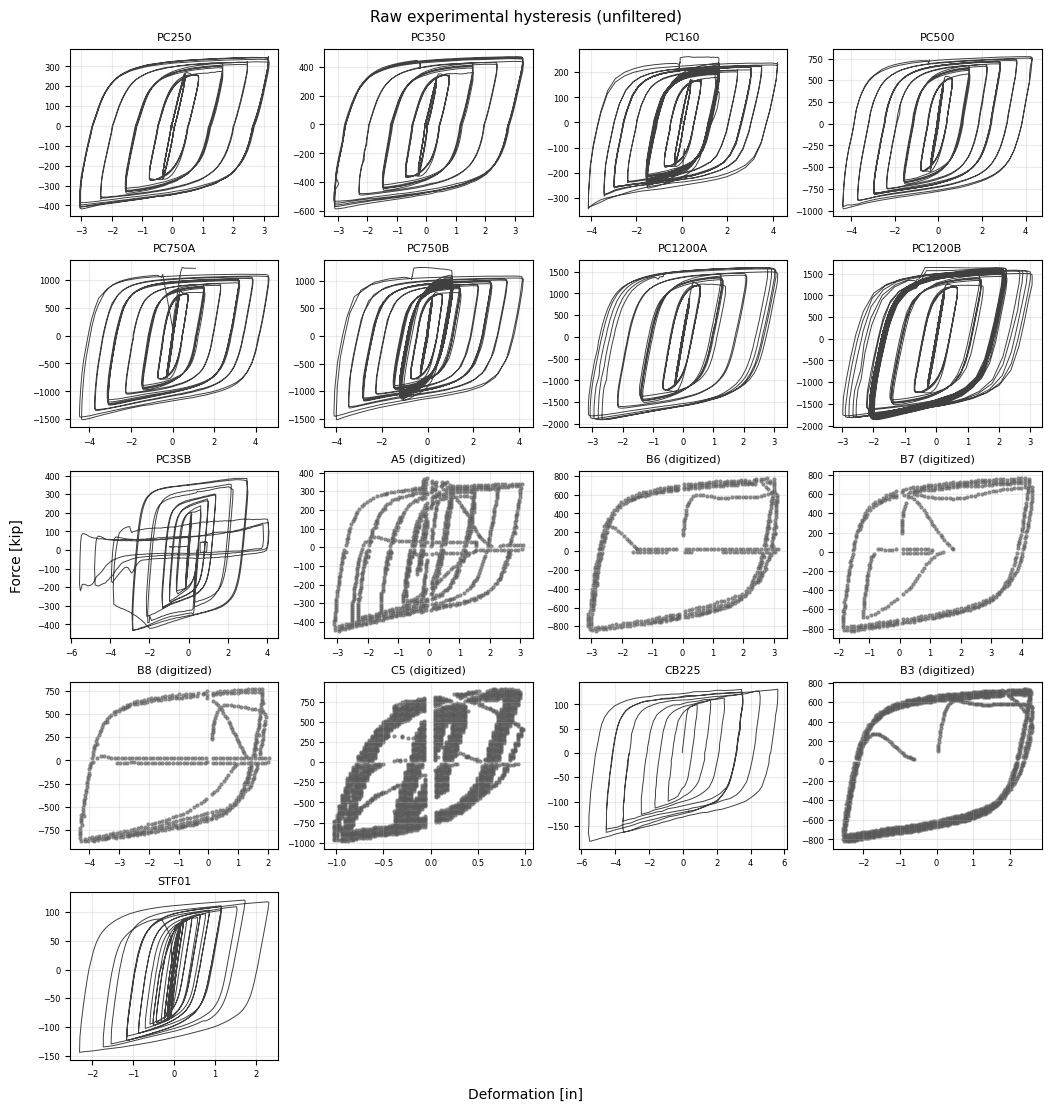

catalog rows: 17


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts" / "examples" / "notebook_support.py").is_file():
    for cand in (ROOT, *ROOT.parents):
        if (cand / "scripts" / "examples" / "notebook_support.py").is_file():
            ROOT = cand
            break
    else:
        raise SystemExit("Could not find BRB-Calibration repo root (need scripts/examples/notebook_support.py).")
import os
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "scripts" / "examples"))
import importlib
import notebook_support
importlib.reload(notebook_support)
from notebook_support import show_specimen_catalog  # noqa: E402

catalog = show_specimen_catalog()
print("catalog rows:", len(catalog))


## What the objective measures

We ask the optimizer to make the model hysteresis look like the experiment.
It does that by minimizing a **weighted sum** of a few error terms:

`J_total = Σ w_k · metric_k`

| Weight | Plain-language meaning |
|--------|------------------------|
| `w_feat_l2` / `w_feat_l1` | How well we hit the **important points** on each cycle (peaks, unload, re-yield). Demos usually turn **exactly one** of these on (set to 1). |
| `w_energy_l2` / `w_energy_l1` | How well per-cycle **energy** (`|∫ F du|`) matches. Usually left at 0. |
| `w_unordered_binenv_l2` / `w_unordered_binenv_l1` | How well the **outer force envelope** matches when you only have a cloud of `(D, F)` points (digitized tests). Usually weight 0 in the fit; still reported as a diagnostic. |

Even when a weight is 0, the metrics tables still **print** that column so you can look at it.

## Amplitude weighting (inside the point-match term)

These settings do **not** add a new term. They only change how cycles are mixed
**inside** the characteristic-point error `J_feat`:

`J_feat = Σ_c w_c · j_c / Σ_c w_c`

| Setting | Effect |
|---------|--------|
| `use_amplitude_weights=False` | Every cycle counts equally (`w_c = 1`). |
| `use_amplitude_weights=True` | Larger cycles count more: `w_c = (A_c / A_max)^p + ε`. |
| `amplitude_weight_power` (`p`) | How strongly amplitude boosts the weight. |
| `amplitude_weight_eps` (`ε`) | Small floor so tiny cycles are not ignored completely. |


## What `J_binenv` is

Some validation specimens are **digitized clouds**: many `(deformation, force)`
points with no reliable cycle-by-cycle time order. For those, the usual
characteristic-point score is not a fair comparison.

`J_binenv` (binned envelope) is the alternative:

1. Slice the deformation axis into bins.
2. In each bin, read the **highest** and **lowest** force on the experiment and
   on the model.
3. Score how well those upper/lower envelopes match.

So: **for digitized validation, look at `J_binenv` first.** Train specimens also
report it, which makes train vs validation easier to compare on one scale.
(The fit usually leaves the binenv **weight** at 0; the column is still filled
for reporting.)


## Parameters

- `TRAIN_SPECIMENS` — who enters the joint fit, and with what relative weight.
- `VALIDATION_SPECIMENS` — held out: metrics and overlays only (weight 0).
- `SET_ID_ROW` — shared SteelMPF seeds, free parameters, and loss weights.


In [2]:
from pathlib import Path
import sys

# --- edit these ---
# Name -> specimen weight in the joint objective (default 1).
TRAIN_SPECIMENS = {
    "PC250": 1.0,
    "PC3SB": 1.0,
    "PC160": 1.0,
}
# Validation (not in the joint fit): path-ordered + digitized unordered.
# B6 ≈ constant large cycles; CB225 = growing multi-amplitude protocol.
VALIDATION_SPECIMENS = ["PC350", "B6", "CB225"]
PREPARE_DATA = True

SET_ID_ROW = {
    "set_id": 1,
    "inherit_from_set": -999,
    "E": 29000,
    "b_p": 0.005,
    "b_n": 0.025,
    "R0": 20,
    "cR1": 0.8875,
    "cR2": 0.15,
    "a1": 0.04,
    "a2": 1.0,
    "a3": 0.04,
    "a4": 1.0,
    "optimize_params": ["b_p", "b_n", "cR1", "cR2", "a1", "a3"],
    "w_feat_l2": 1,
    "w_feat_l1": 0,
    "w_energy_l2": 0,
    "w_energy_l1": 0,
    "w_unordered_binenv_l2": 0,
    "w_unordered_binenv_l1": 0,
    "use_amplitude_weights": True,
    "amplitude_weight_power": 2,
    "amplitude_weight_eps": 0.05,
}
# ------------------

ROOT = Path.cwd().resolve()
if not (ROOT / "scripts" / "examples" / "notebook_support.py").is_file():
    for cand in (ROOT, *ROOT.parents):
        if (cand / "scripts" / "examples" / "notebook_support.py").is_file():
            ROOT = cand
            break
    else:
        raise SystemExit("Could not find BRB-Calibration repo root (need scripts/examples/notebook_support.py).")
import os
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "scripts" / "examples"))
from notebook_support import (  # noqa: E402
    digitized_unordered_sim_arrays,
    ensure_sys_path,
    load_experiment_force_disp,
    params_dict_from_row,
    run_generalized_demo,
    simulate_force_disp,
    summarize_generalized_train_validation_metrics,
)
ensure_sys_path()
print("train weights:", TRAIN_SPECIMENS)
print("validation:", VALIDATION_SPECIMENS)
print("feat weights: L2=", SET_ID_ROW["w_feat_l2"], "L1=", SET_ID_ROW["w_feat_l1"])


train weights: {'PC250': 1.0, 'PC3SB': 1.0, 'PC160': 1.0}
validation: ['PC350', 'B6', 'CB225']
feat weights: L2= 1 L1= 0


## Run generalized optimize

Learns **one** shared SteelMPF vector from the weighted train list, then scores
train and validation specimens. Validation names never enter the fit — they are
a hold-out check.


In [3]:
paths = run_generalized_demo(
    TRAIN_SPECIMENS,
    set_id_row=SET_ID_ROW,
    eval_specimens=VALIDATION_SPECIMENS,
    prepare_data=PREPARE_DATA,
)
print("params: ", paths["params"])
print("metrics:", paths["metrics"])
print("plots:  ", paths["plots_dir"])
print("weights:", paths["train_weights"])
print("validation:", paths.get("validation_specimens", paths["eval_specimens"]))


Preparing data for 'PC250'...
  Preparing data for 'PC250'...
    cycle_points: 132 points, 132 segments (wrote JSON)
Skip filtering PC250: min segment length 1 < 11
Wrote data\filtered\PC250/{force_deformation,deformation_history}.csv
    filter_force: done


  PC250: resampled n=2060 (filtered n=16325), D_sampling=0.066456 in
    resample_filtered: done
Preparing data for 'PC3SB'...
  Preparing data for 'PC3SB'...


    cycle_points: 91 points, 91 segments (wrote JSON)
Skip filtering PC3SB: min segment length 6 < 11


Wrote data\filtered\PC3SB/{force_deformation,deformation_history}.csv
    filter_force: done


  PC3SB: resampled n=2487 (filtered n=99649), D_sampling=0.0282069 in
    resample_filtered: done
Preparing data for 'PC160'...
  Preparing data for 'PC160'...


...

Wrote data\filtered\PC160/{force_deformation,deformation_history}.csv
    filter_force: done


  PC160: resampled n=4838 (filtered n=34100), D_sampling=0.0653679 in
    resample_filtered: done
Preparing data for 'PC350'...
  Preparing data for 'PC350'...
    cycle_points: 134 points, 134 segments (wrote JSON)
Skip filtering PC350: min segment length 4 < 11
Wrote data\filtered\PC350/{force_deformation,deformation_history}.csv
    filter_force: done


  PC350: resampled n=2012 (filtered n=17500), D_sampling=0.0677078 in
    resample_filtered: done
Preparing data for 'CB225'...
  Preparing data for 'CB225'...
    cycle_points: 46 points, 46 segments (wrote JSON)
CB225: skip_filter_resample -> filtered = trim-valid raw (no Savitzky-Golay)
Wrote data\filtered\CB225/{force_deformation,deformation_history}.csv
    filter_force: done


  CB225: resampled n=1514 (filtered n=486), D_sampling=0.0682067 in
    resample_filtered: done
+ C:\Users\garaujor\AppData\Local\anaconda3\envs\py312\python.exe C:\Users\garaujor\source\repos\BRB-Calibration\scripts\calibrate\optimize_generalized_brb_mse.py --set-id-settings C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized\set_id_settings_generalized.csv --train-specimens PC250:1,PC3SB:1,PC160:1 --output-params C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized\generalized_brb_parameters.csv --output-metrics C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized\generalized_params_eval_metrics.csv --output-plots-dir C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized\overlays --output-cloud-plots-dir C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized\overlays --eval-specimens PC350,B6,CB225


params:  C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized\generalized_brb_parameters.csv
metrics: C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized\generalized_params_eval_metrics.csv
plots:   C:\Users\garaujor\source\repos\BRB-Calibration\results\notebooks\generalized\overlays
weights: {'PC250': 1.0, 'PC3SB': 1.0, 'PC160': 1.0}
validation: ['PC350', 'B6', 'CB225']


## Results — train vs validation

Two scores show up a lot:

- **`J_feat`** — characteristic-point match (path-ordered cycles; what the fit
  usually minimizes).
- **`J_binenv`** — envelope match (especially useful for digitized clouds; also
  printed for path-ordered tests so everything shares one scale).

Rule of thumb: train specimens should tend to look **better** (lower scores)
than validation specimens the model has not seen.


,Name,set_id,b_p,b_n,R0,cR1,cR2,a1,a3
0,B6,1,0.005006,0.020773,20.0,0.8838,0.109538,0.034512,0.03336
1,CB225,1,0.005006,0.020773,20.0,0.8838,0.109538,0.034512,0.03336
2,PC160,1,0.005006,0.020773,20.0,0.8838,0.109538,0.034512,0.03336
3,PC250,1,0.005006,0.020773,20.0,0.8838,0.109538,0.034512,0.03336
4,PC350,1,0.005006,0.020773,20.0,0.8838,0.109538,0.034512,0.03336
5,PC3SB,1,0.005006,0.020773,20.0,0.8838,0.109538,0.034512,0.03336


,Name,role,J_feat,J_binenv,J_total,specimen_weight
0,PC160,train,0.000465,0.001356,0.000465,1.0
1,PC250,train,0.000207,0.000499,0.000207,1.0
2,PC3SB,train,0.000315,0.000595,0.000315,1.0
3,B6,validation,NaN,0.004928,NaN,0.0
4,CB225,validation,0.001004,0.001997,0.001004,0.0
5,PC350,validation,0.000125,0.000700,0.000125,0.0


mean J_binenv  train=0.000816602  validation=0.00254158


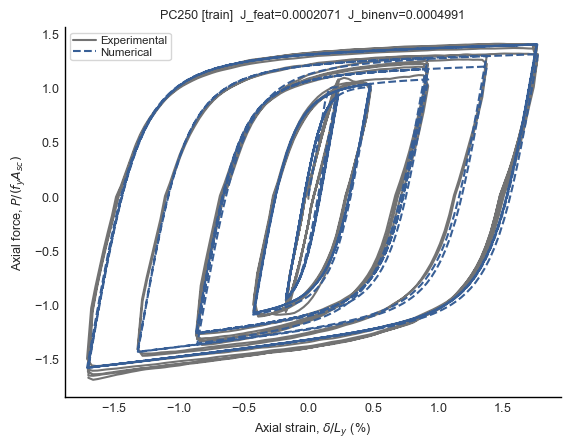

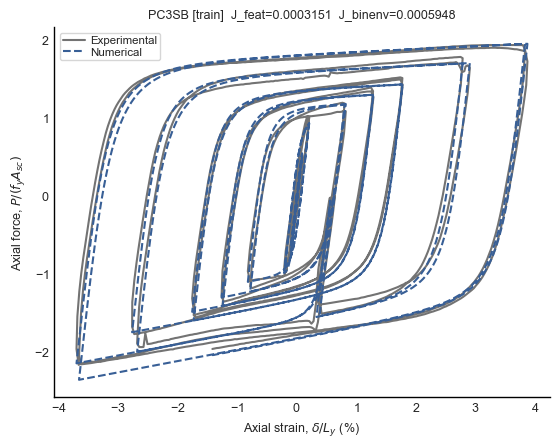

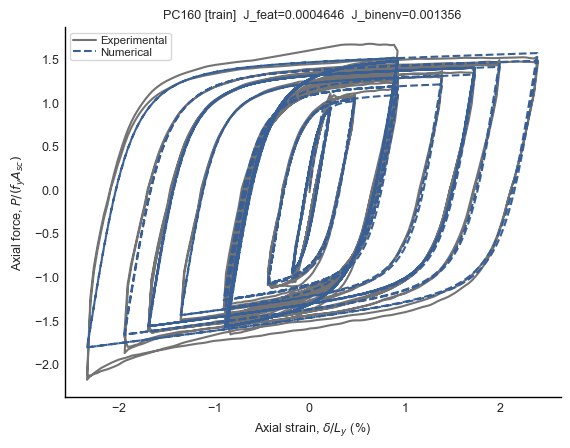

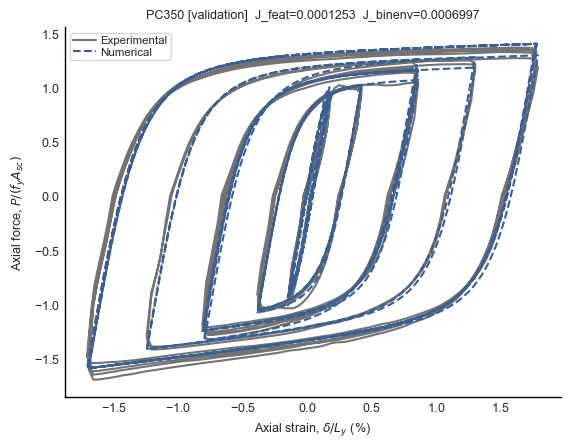

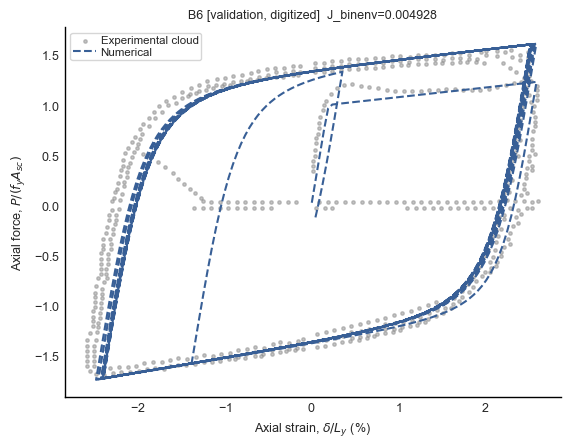

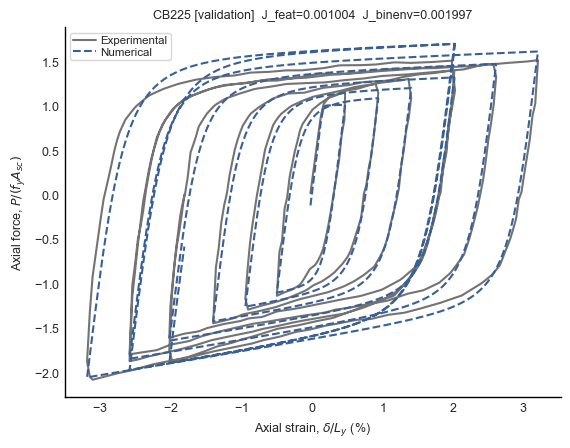

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

params = pd.read_csv(paths["params"])
metrics = pd.read_csv(paths["metrics"])
display(params[["Name", "set_id", "b_p", "b_n", "R0", "cR1", "cR2", "a1", "a3"]].head(12))

cmp = summarize_generalized_train_validation_metrics(
    metrics,
    train_names=list(TRAIN_SPECIMENS),
    eval_names=VALIDATION_SPECIMENS,
)
display(cmp)

train_bin = cmp.loc[cmp["role"] == "train", "J_binenv"]
val_bin = cmp.loc[cmp["role"] == "validation", "J_binenv"]
if len(train_bin) and len(val_bin):
    print(
        f"mean J_binenv  train={train_bin.mean():.6g}  "
        f"validation={val_bin.mean():.6g}"
    )

sid = int(SET_ID_ROW["set_id"])

# Train path-ordered overlays
for name in TRAIN_SPECIMENS:
    row = params[(params["Name"].astype(str) == name) & (params["set_id"] == sid)].iloc[0]
    p = params_dict_from_row(row)
    exp_disp, exp_force = load_experiment_force_disp(name)
    num_disp, num_force = simulate_force_disp(exp_disp, **p)
    fyA = p["fyp"] * p["A_sc"]
    jrow = cmp.loc[cmp["Name"] == name].iloc[0]
    plt.figure()
    plt.plot(100.0 * exp_disp / p["L_y"], exp_force / fyA, color="0.45", label="Experimental")
    plt.plot(100.0 * num_disp / p["L_y"], num_force / fyA, linestyle="--", label="Numerical")
    plt.xlabel(r"Axial strain, $\delta / L_y$ (%)")
    plt.ylabel(r"Axial force, $P / (f_y A_{sc})$")
    plt.title(
        f"{name} [train]  J_feat={jrow['J_feat']:.4g}  J_binenv={jrow['J_binenv']:.4g}"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Validation: path-ordered hysteresis or digitized cloud
from specimen_catalog import get_specimen_record, read_catalog, uses_unordered_inputs

_cat = read_catalog()
for name in VALIDATION_SPECIMENS:
    rows = params[(params["Name"].astype(str) == name) & (params["set_id"] == sid)]
    if rows.empty:
        print(f"(skip {name}: no params row)")
        continue
    p = params_dict_from_row(rows.iloc[0])
    jrow = cmp.loc[cmp["Name"] == name]
    j_feat = float(jrow["J_feat"].iloc[0]) if len(jrow) else float("nan")
    j_bin = float(jrow["J_binenv"].iloc[0]) if len(jrow) else float("nan")
    if uses_unordered_inputs(get_specimen_record(name, _cat)):
        dig = digitized_unordered_sim_arrays(name, p)
        fyA = p["fyp"] * p["A_sc"]
        plt.figure()
        plt.scatter(
            100.0 * dig["u_cloud"] / p["L_y"],
            dig["F_cloud"] / fyA,
            s=6,
            c="0.55",
            alpha=0.5,
            label="Experimental cloud",
        )
        plt.plot(
            100.0 * dig["D_drive"] / p["L_y"],
            dig["F_sim"] / fyA,
            linestyle="--",
            label="Numerical",
        )
        plt.xlabel(r"Axial strain, $\delta / L_y$ (%)")
        plt.ylabel(r"Axial force, $P / (f_y A_{sc})$")
        plt.title(f"{name} [validation, digitized]  J_binenv={j_bin:.4g}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        continue

    exp_disp, exp_force = load_experiment_force_disp(name)
    num_disp, num_force = simulate_force_disp(exp_disp, **p)
    fyA = p["fyp"] * p["A_sc"]
    plt.figure()
    plt.plot(100.0 * exp_disp / p["L_y"], exp_force / fyA, color="0.45", label="Experimental")
    plt.plot(100.0 * num_disp / p["L_y"], num_force / fyA, linestyle="--", label="Numerical")
    plt.xlabel(r"Axial strain, $\delta / L_y$ (%)")
    plt.ylabel(r"Axial force, $P / (f_y A_{sc})$")
    plt.title(f"{name} [validation]  J_feat={j_feat:.4g}  J_binenv={j_bin:.4g}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
